<a href="https://colab.research.google.com/github/dionysus-laughed/school_cs4410/blob/main/summers_hw6_cs4410.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import nltk
from textblob import TextBlob
import requests
import imageio.v3 as iio
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Required NLTK downloads
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4') # Often required for Lemmatization in TextBlob

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
# Fetch Hamlet text
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

# Fetch Mask Image
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = iio.imread(image_file)

print(f"Text length: {len(data)} characters")
print("Mask image loaded successfully.")

Text length: 171696 characters
Mask image loaded successfully.


In [12]:
nltk.download('punkt_tab', quiet=True)
# Create TextBlob object
blob = TextBlob(data)

# Get the list of standard NLTK stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Add specific words you might want to ignore (optional)
# stop_words.update(['the', 'and', 'hamlet'])

# Filter out stop words and non-alphabetic tokens
items = blob.word_counts.items()
filtered_items = {word: count for word, count in items if word not in stop_words and word.isalpha()}

# Join words back into a single string for the WordCloud
cleaned_text = " ".join([word for word, count in filtered_items.items() for _ in range(count)])

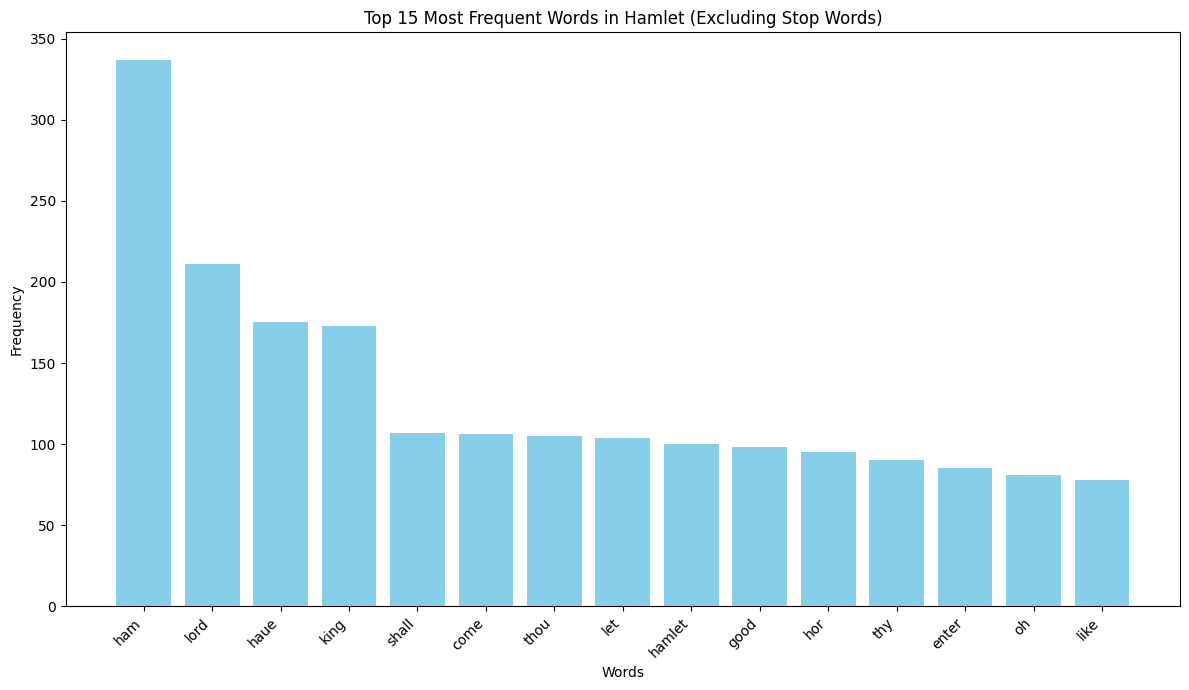

In [13]:
import matplotlib.pyplot as plt

# Sort the filtered_items by count in descending order
sorted_words = sorted(filtered_items.items(), key=lambda item: item[1], reverse=True)

# Get the top N words (e.g., top 15)
top_n_words = 15
words = [item[0] for item in sorted_words[:top_n_words]]
counts = [item[1] for item in sorted_words[:top_n_words]]

# Create the bar chart
plt.figure(figsize=(12, 7))
plt.bar(words, counts, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title(f'Top {top_n_words} Most Frequent Words in Hamlet (Excluding Stop Words)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

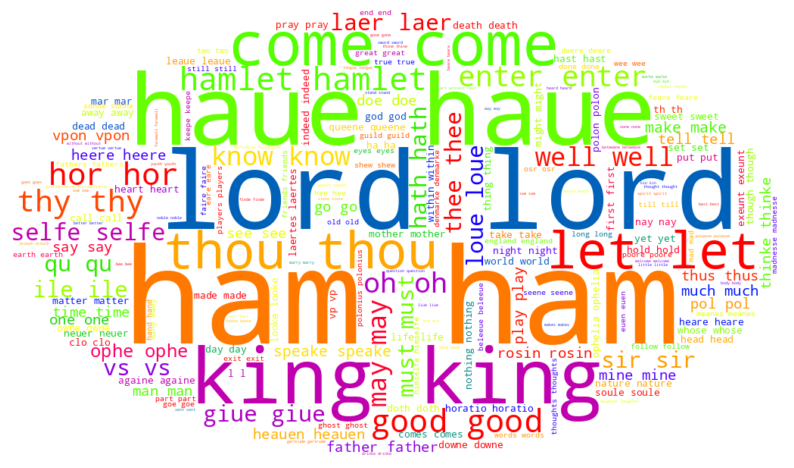

In [14]:
# Configure WordCloud
wordcloud = WordCloud(
    width=1000,
    height=1000,
    colormap='prism',
    mask=mask_image,
    background_color='white'
)

# Generate word cloud
wordcloud = wordcloud.generate(cleaned_text)

# Display the image
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()